In [ ]:
!pip install prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# Load data
data = pd.read_csv("/air_pollution_data.csv")
print("Initial data:")
print(data.head())

# Check missing values
print("\nMissing values:")
print(data.isnull().sum())

# Data info and summary
print("\nData Info:")
print(data.info())
print("\nData Description:")
print(data.describe())

# ------------------------------
# 3. Data Preprocessing
### - Replaced invalid entries with NaN
##- Filled missing values using column mean
##- Combined 'date' and 'time' into a single datetime column


# Replace -200 with NaN and fill with column means (if any such value existed)
data.replace(-200, np.nan, inplace=True)
data.fillna(data.mean(numeric_only=True), inplace=True)

# Convert 'date' column to datetime
data['datetime'] = pd.to_datetime(data['date'])
data.set_index('datetime', inplace=True)
data.drop(columns=['date'], inplace=True)

# ------------------------------
# 4. Feature Engineering

# Select important features
features = data[['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']]

# Scale the features

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns, index=data.index)



Initial data:
        city        date  aqi       co     no    no2      o3    so2   pm2_5  \
0  Ahmedabad  30-11-2020    5   520.71   2.38  16.28  130.18  47.68   65.96   
1  Ahmedabad  01-12-2020    5  1682.28   7.71  54.84    0.73  21.70  120.95   
2  Ahmedabad  02-12-2020    5  1815.80  16.54  49.35    0.17  23.84  133.47   
3  Ahmedabad  03-12-2020    5  2296.45  41.57  40.10    0.00  35.76  150.37   
4  Ahmedabad  04-12-2020    5  2189.64  23.92  58.95    0.02  28.13  160.79   

     pm10    nh3  
0   72.13   8.36  
1  154.53  27.36  
2  172.63  28.12  
3  202.15  36.48  
4  205.80  40.53  

Missing values:
city     0
date     0
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   date    2

<ipython-input-41-152e0292b415>:28: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/hguvt8sm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/65ghnnqh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19904', 'data', 'file=/tmp/tmpvmh_9yok/hguvt8sm.json', 'init=/tmp/tmpvmh_9yok/65ghnnqh.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modeltpdjib98/prophet_model-20250508112942.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:29:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:29:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


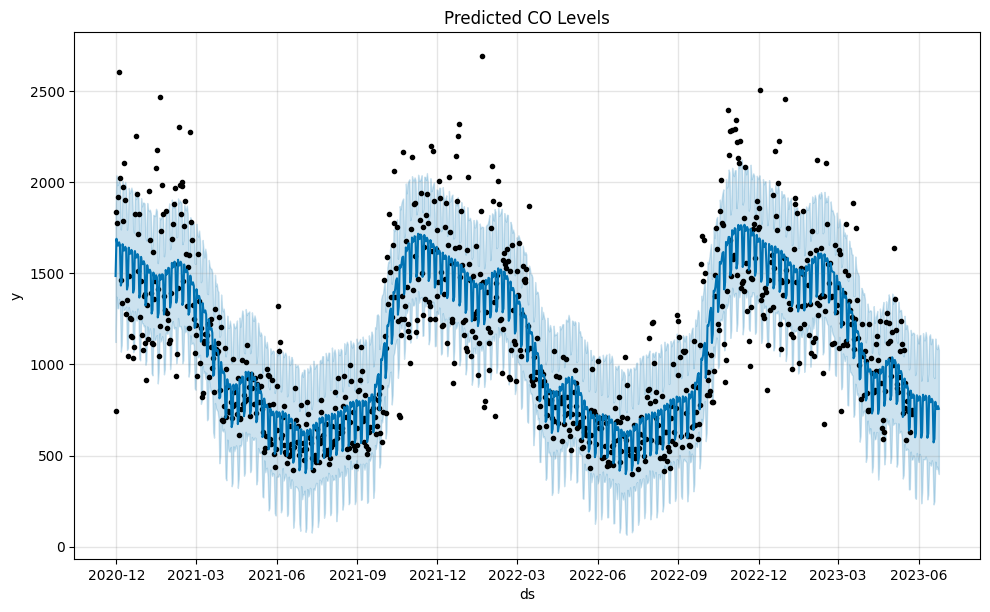


CO Model Evaluation Metrics:
MAE: 213.15
RMSE: 278.83
R^2 Score: 0.64


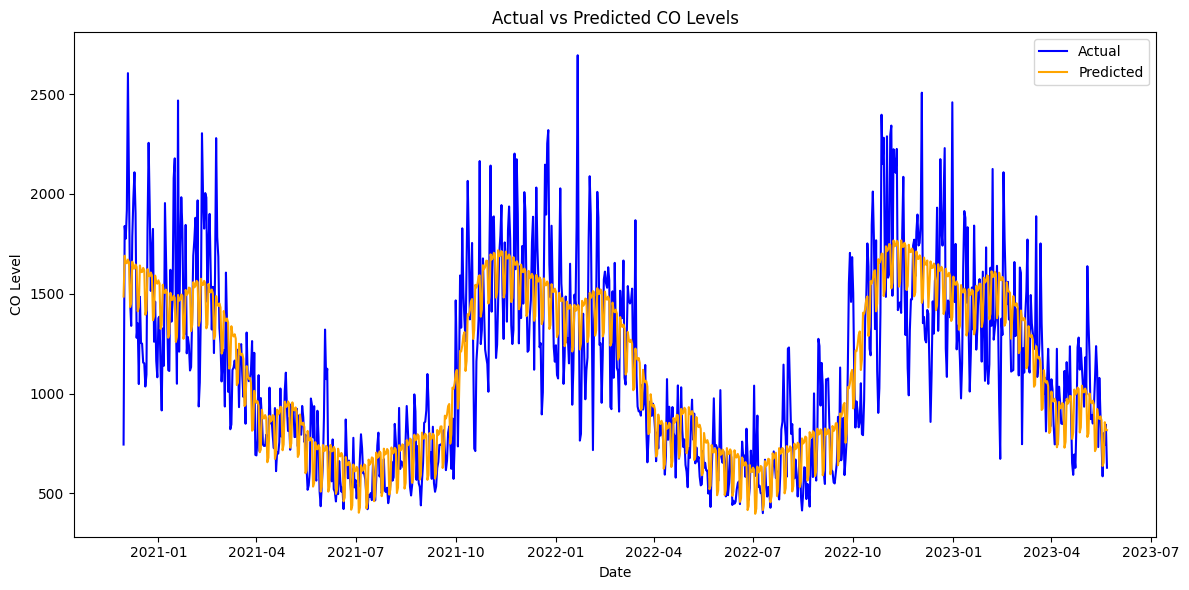

Forecast saved to 'co_forecast.csv'


In [ ]:
# ------------------------------
# Model Development using Prophet (CO)

# Prepare data for Prophet - CO
prophet_data_co = data[['co']].reset_index()
prophet_data_co.columns = ['ds', 'y']
prophet_data_co = prophet_data_co.resample('D', on='ds').mean().reset_index()
prophet_data_co.dropna(inplace=True)

model_co = Prophet()
model_co.fit(prophet_data_co)

future_co = model_co.make_future_dataframe(periods=30)
forecast_co = model_co.predict(future_co)

# ------------------------------
# Model Evaluation - CO

fig1 = model_co.plot(forecast_co)
plt.title('Predicted CO Levels')
plt.show()


forecast_truncated_co = forecast_co[forecast_co['ds'].isin(prophet_data_co['ds'])]

valid_index_co = ~prophet_data_co['y'].isna() & ~forecast_truncated_co['yhat'].isna()
y_true_co = prophet_data_co.loc[valid_index_co, 'y'].values
y_pred_co = forecast_truncated_co.loc[valid_index_co, 'yhat'].values

mae_co = mean_absolute_error(y_true_co, y_pred_co)
rmse_co = np.sqrt(mean_squared_error(y_true_co, y_pred_co))
r2_co = r2_score(y_true_co, y_pred_co)

print(f'\nCO Model Evaluation Metrics:')
print(f'MAE: {mae_co:.2f}')
print(f'RMSE: {rmse_co:.2f}')
print(f'R^2 Score: {r2_co:.2f}')

comparison_df_co = pd.DataFrame({
    'ds': prophet_data_co.loc[valid_index_co, 'ds'],
    'Actual': y_true_co,
    'Predicted': y_pred_co
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_co['ds'], comparison_df_co['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_co['ds'], comparison_df_co['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('CO Level')
plt.title('Actual vs Predicted CO Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_co[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('co_forecast.csv', index=False)
print("Forecast saved to 'co_forecast.csv'")



INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/vzuzzj8w.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/jj6ddboa.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=4815', 'data', 'file=/tmp/tmpvmh_9yok/vzuzzj8w.json', 'init=/tmp/tmpvmh_9yok/jj6ddboa.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelvv47o78m/prophet_model-20250508105840.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:58:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:58:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


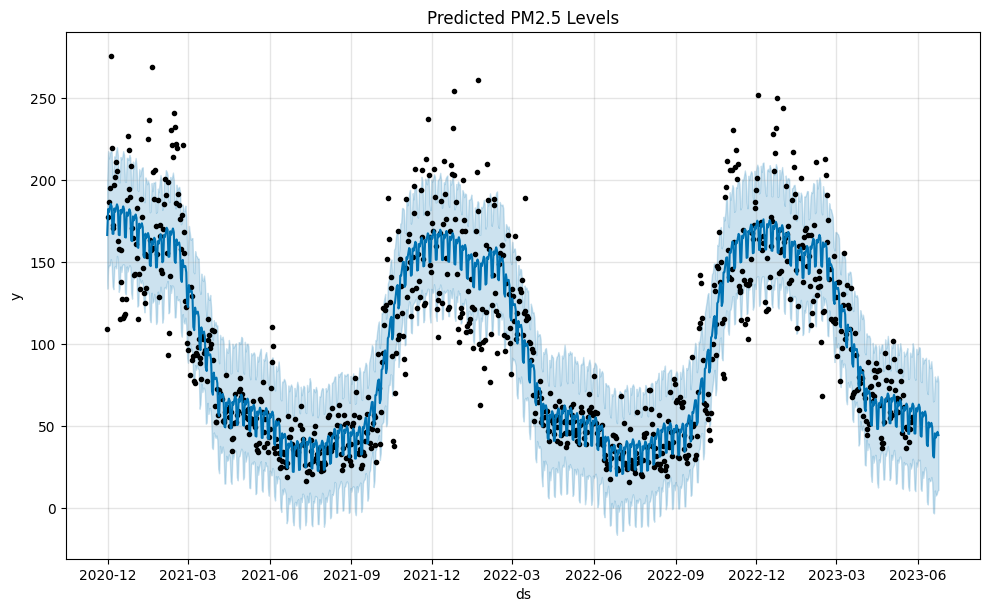


PM2.5 Model Evaluation Metrics:
MAE: 20.37
RMSE: 27.34
R^2 Score: 0.78


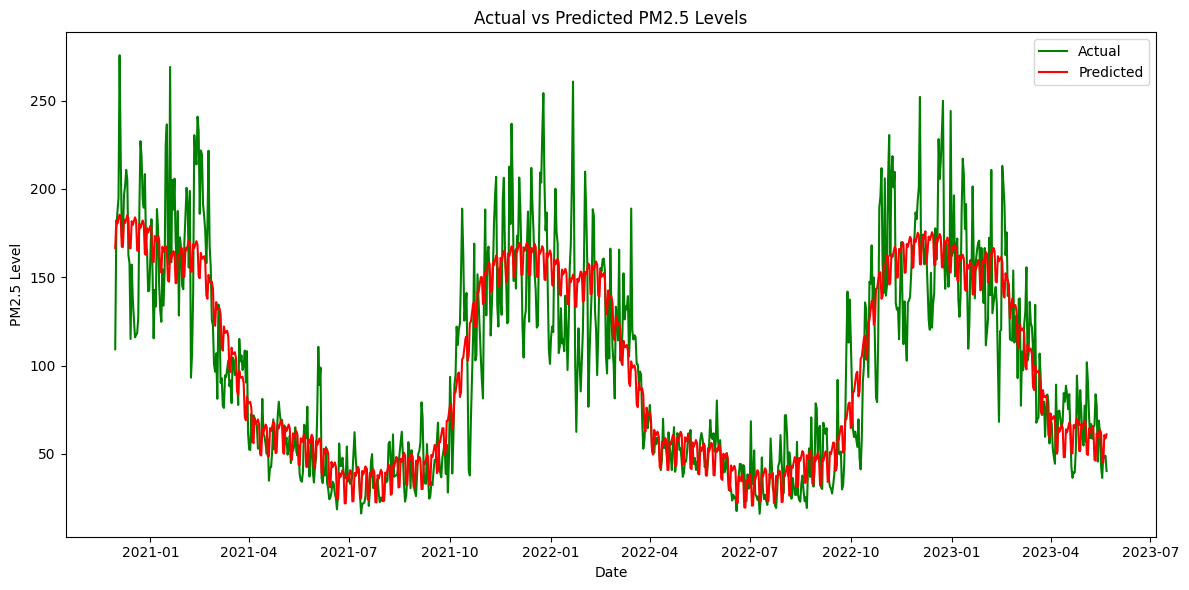

Forecast saved to 'pm25_forecast.csv'


In [ ]:
# ------------------------------
# Repeat Process for PM2.5

# Prepare data for Prophet - PM2.5
prophet_data_pm = data[['pm2_5']].reset_index()
prophet_data_pm.columns = ['ds', 'y']
prophet_data_pm = prophet_data_pm.resample('D', on='ds').mean().reset_index()
prophet_data_pm.dropna(inplace=True)

model_pm = Prophet()
model_pm.fit(prophet_data_pm)

future_pm = model_pm.make_future_dataframe(periods=30)
forecast_pm = model_pm.predict(future_pm)

# Evaluation - PM2.5
fig2 = model_pm.plot(forecast_pm)
plt.title('Predicted PM2.5 Levels')
plt.show()

forecast_truncated_pm = forecast_pm[forecast_pm['ds'].isin(prophet_data_pm['ds'])]

valid_index_pm = ~prophet_data_pm['y'].isna() & ~forecast_truncated_pm['yhat'].isna()
y_true_pm = prophet_data_pm.loc[valid_index_pm, 'y'].values
y_pred_pm = forecast_truncated_pm.loc[valid_index_pm, 'yhat'].values

mae_pm = mean_absolute_error(y_true_pm, y_pred_pm)
rmse_pm = np.sqrt(mean_squared_error(y_true_pm, y_pred_pm))
r2_pm = r2_score(y_true_pm, y_pred_pm)

print(f'\nPM2.5 Model Evaluation Metrics:')
print(f'MAE: {mae_pm:.2f}')
print(f'RMSE: {rmse_pm:.2f}')
print(f'R^2 Score: {r2_pm:.2f}')

comparison_df_pm = pd.DataFrame({
    'ds': prophet_data_pm.loc[valid_index_pm, 'ds'],
    'Actual': y_true_pm,
    'Predicted': y_pred_pm
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_pm['ds'], comparison_df_pm['Actual'], label='Actual', color='green')
plt.plot(comparison_df_pm['ds'], comparison_df_pm['Predicted'], label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('PM2.5 Level')
plt.title('Actual vs Predicted PM2.5 Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_pm[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('pm25_forecast.csv', index=False)
print("Forecast saved to 'pm25_forecast.csv'")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/jf88aora.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/w13rhvrz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69585', 'data', 'file=/tmp/tmpvmh_9yok/jf88aora.json', 'init=/tmp/tmpvmh_9yok/w13rhvrz.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_model8n0by36p/prophet_model-20250508105822.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:58:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:58:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


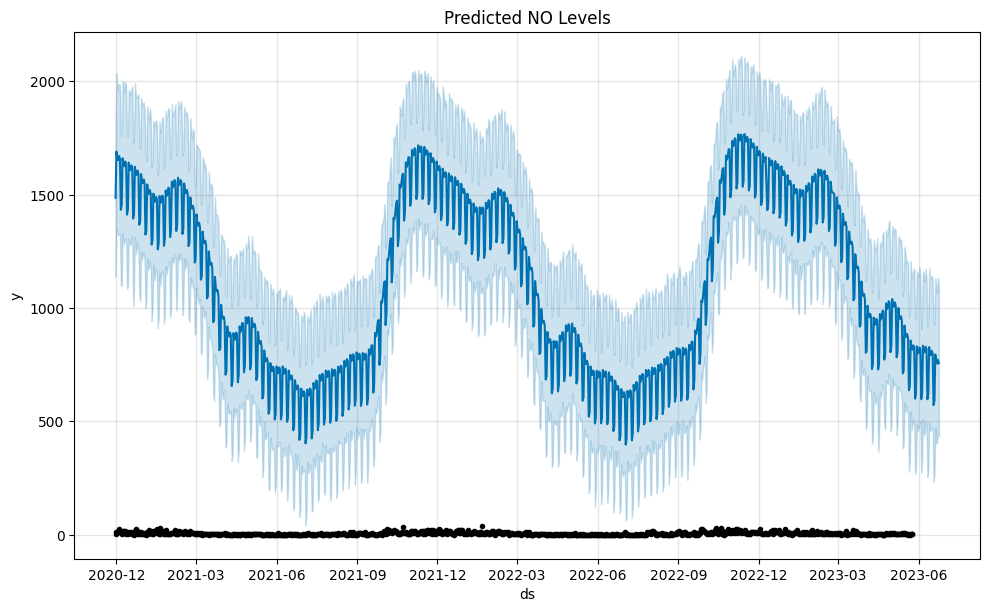


NO Model Evaluation Metrics:
MAE: 1107.03
RMSE: 1171.31
R^2 Score: -36796.71


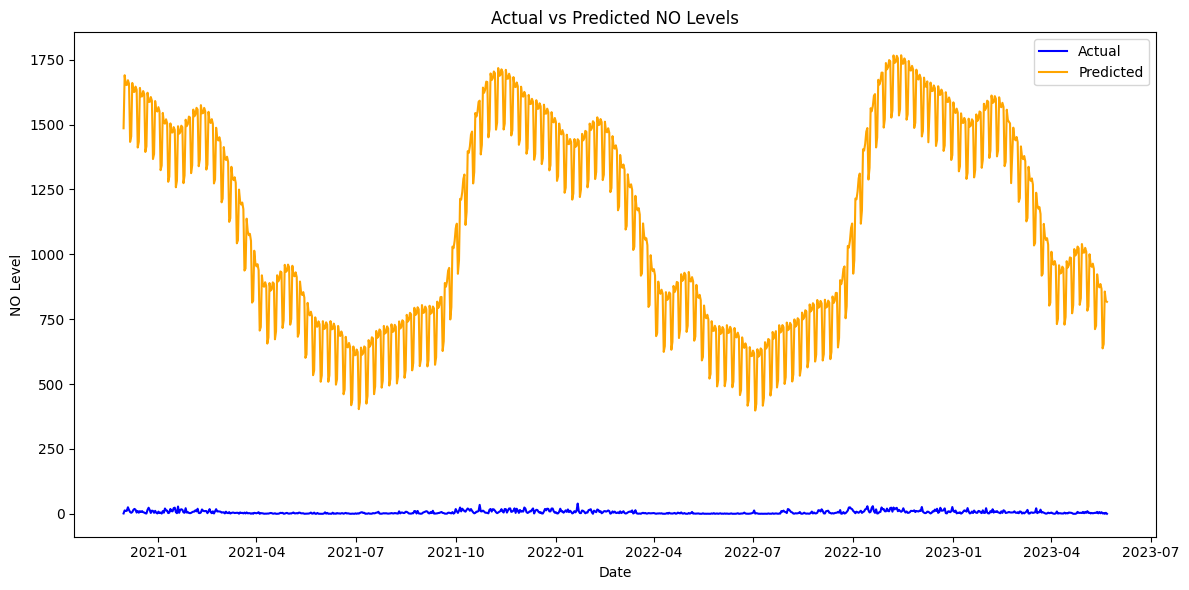

Forecast saved to 'no_forecast.csv'


In [ ]:
# ------------------------------
# Model Development using Prophet (NO)

# Prepare data for Prophet - NO
prophet_data_no = data[['no']].reset_index()
prophet_data_no.columns = ['ds', 'y']
prophet_data_no = prophet_data_no.resample('D', on='ds').mean().reset_index()
prophet_data_no.dropna(inplace=True)

model_no = Prophet()
model_no.fit(prophet_data_no)

future_no = model_co.make_future_dataframe(periods=30)
forecast_no = model_co.predict(future_no)

# ------------------------------
#  Model Evaluation - NO

fig1 = model_no.plot(forecast_no)
plt.title('Predicted NO Levels')
plt.show()


forecast_truncated_no = forecast_no[forecast_no['ds'].isin(prophet_data_no['ds'])]

valid_index_no = ~prophet_data_no['y'].isna() & ~forecast_truncated_no['yhat'].isna()
y_true_no = prophet_data_no.loc[valid_index_no, 'y'].values
y_pred_no = forecast_truncated_no.loc[valid_index_no, 'yhat'].values

mae_no = mean_absolute_error(y_true_no, y_pred_no)
rmse_no = np.sqrt(mean_squared_error(y_true_no, y_pred_no))
r2_no = r2_score(y_true_no, y_pred_no)

print(f'\nNO Model Evaluation Metrics:')
print(f'MAE: {mae_no:.2f}')
print(f'RMSE: {rmse_no:.2f}')
print(f'R^2 Score: {r2_no:.2f}')

comparison_df_no = pd.DataFrame({
    'ds': prophet_data_no.loc[valid_index_no, 'ds'],
    'Actual': y_true_no,
    'Predicted': y_pred_no
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_no['ds'], comparison_df_no['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_no['ds'], comparison_df_no['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('NO Level')
plt.title('Actual vs Predicted NO Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_co[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('no_forecast.csv', index=False)
print("Forecast saved to 'no_forecast.csv'")



# New Section

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/0eb_v_3t.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/8junhdtc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14353', 'data', 'file=/tmp/tmpvmh_9yok/0eb_v_3t.json', 'init=/tmp/tmpvmh_9yok/8junhdtc.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelgaawmp9a/prophet_model-20250508110152.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:01:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:01:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


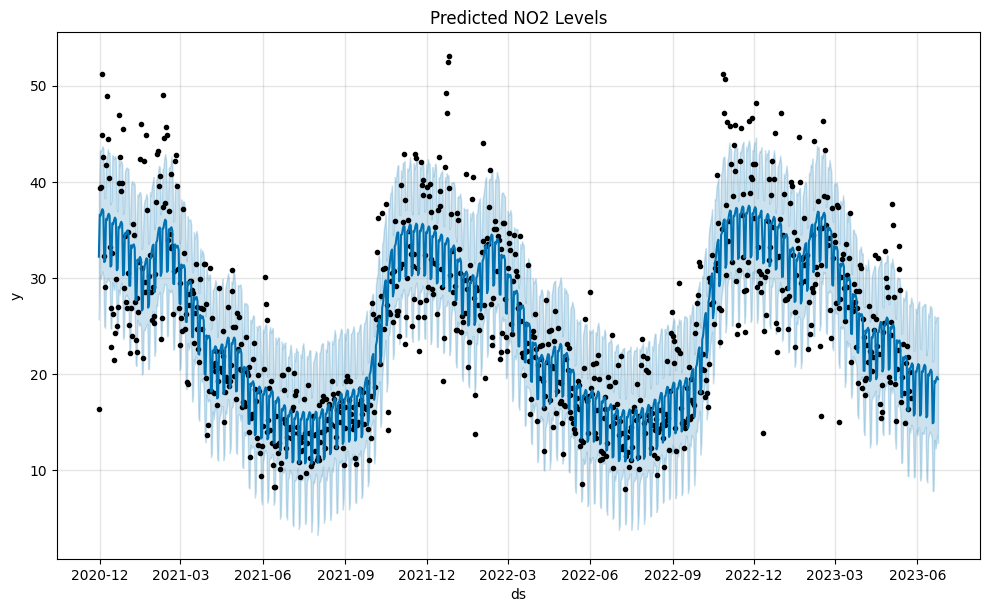


NO2 Model Evaluation Metrics:
MAE: 4.30
RMSE: 5.57
R^2 Score: 0.64


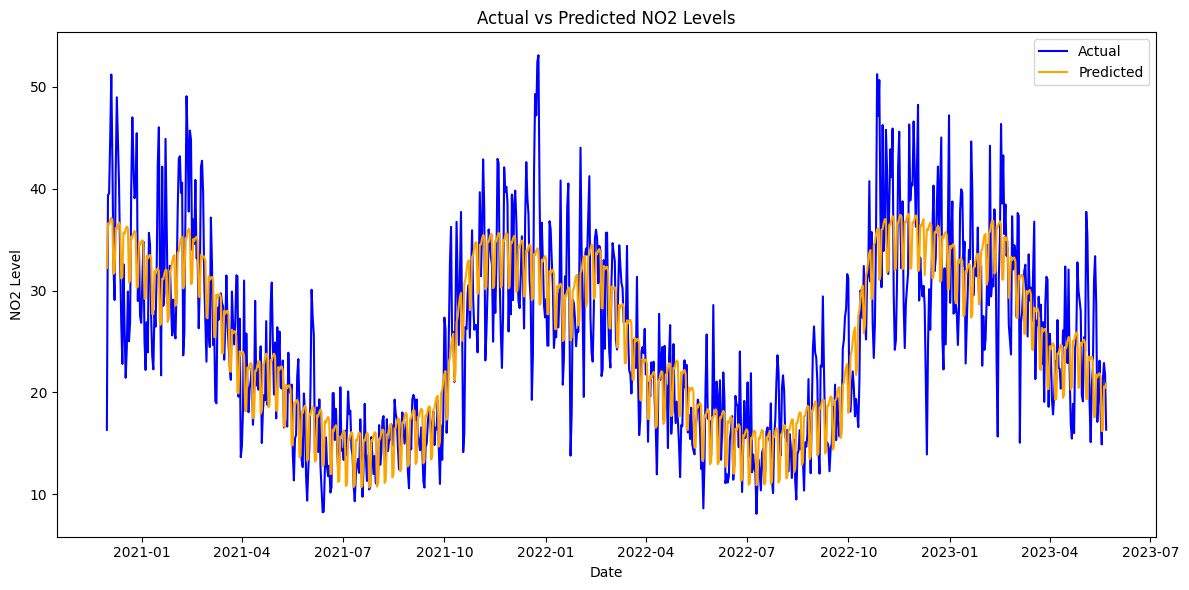

Forecast saved to 'no2_forecast.csv'


In [ ]:
# ------------------------------
# Model Development using Prophet (NO2)

# Prepare data for Prophet - NO2
prophet_data_no2 = data[['no2']].reset_index()
prophet_data_no2.columns = ['ds', 'y']
prophet_data_no2 = prophet_data_no2.resample('D', on='ds').mean().reset_index()
prophet_data_no2.dropna(inplace=True)

model_no2 = Prophet()
model_no2.fit(prophet_data_no2)

future_no2 = model_no2.make_future_dataframe(periods=30)
forecast_no2 = model_no2.predict(future_no2)

# ------------------------------
#  Model Evaluation - NO2

fig1 = model_no2.plot(forecast_no2)
plt.title('Predicted NO2 Levels')
plt.show()

forecast_truncated_no2 = forecast_no2[forecast_no2['ds'].isin(prophet_data_no2['ds'])]

valid_index_no2 = ~prophet_data_no2['y'].isna() & ~forecast_truncated_no2['yhat'].isna()
y_true_no2 = prophet_data_no2.loc[valid_index_no2, 'y'].values
y_pred_no2 = forecast_truncated_no2.loc[valid_index_no2, 'yhat'].values

mae_no2 = mean_absolute_error(y_true_no2, y_pred_no2)
rmse_no2 = np.sqrt(mean_squared_error(y_true_no2, y_pred_no2))
r2_no2 = r2_score(y_true_no2, y_pred_no2)

print(f'\nNO2 Model Evaluation Metrics:')
print(f'MAE: {mae_no2:.2f}')
print(f'RMSE: {rmse_no2:.2f}')
print(f'R^2 Score: {r2_no2:.2f}')

comparison_df_no2 = pd.DataFrame({
    'ds': prophet_data_no2.loc[valid_index_no2, 'ds'],
    'Actual': y_true_no2,
    'Predicted': y_pred_no2
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_no2['ds'], comparison_df_no2['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_no2['ds'], comparison_df_no2['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('NO2 Level')
plt.title('Actual vs Predicted NO2 Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_no2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('no2_forecast.csv', index=False)
print("Forecast saved to 'no2_forecast.csv'")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/_eecyvdo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/6nn6wvbb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=3011', 'data', 'file=/tmp/tmpvmh_9yok/_eecyvdo.json', 'init=/tmp/tmpvmh_9yok/6nn6wvbb.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelt0yushq4/prophet_model-20250508110325.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:03:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:03:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


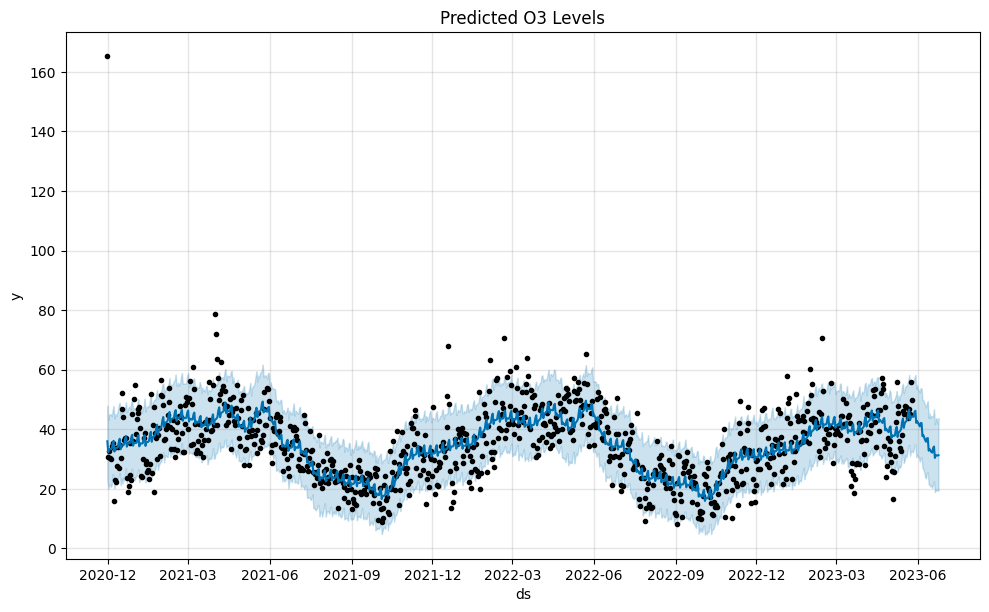


O3 Model Evaluation Metrics:
MAE: 6.38
RMSE: 9.14
R^2 Score: 0.46


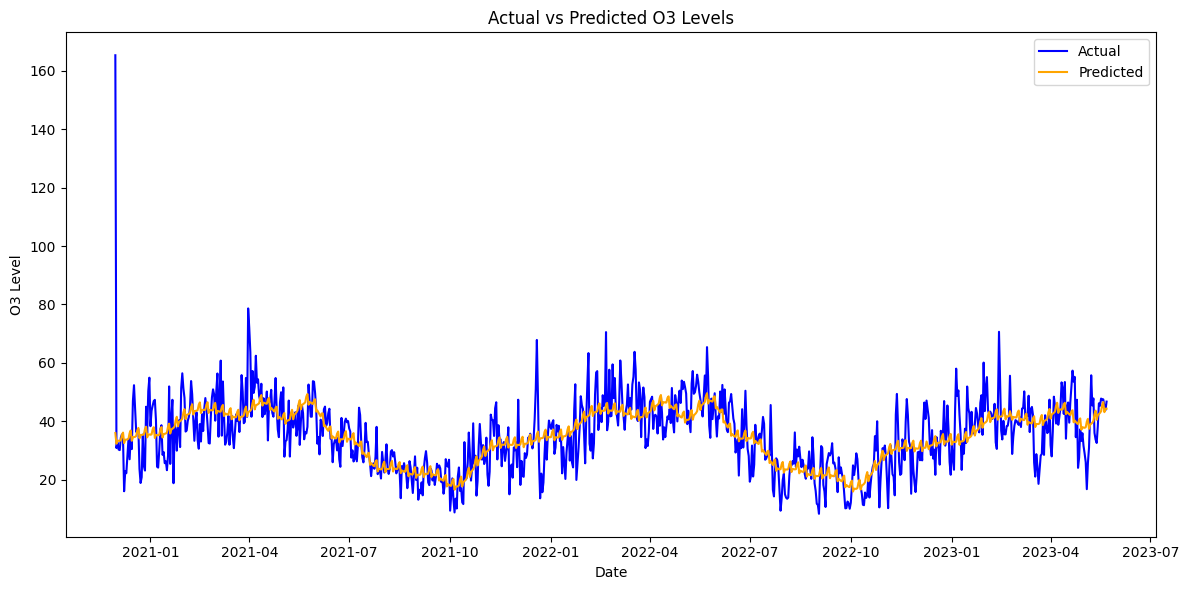

Forecast saved to 'o3_forecast.csv'


In [ ]:
# ------------------------------
#  Model Development using Prophet (O3)

# Prepare data for Prophet - O3
prophet_data_o3 = data[['o3']].reset_index()
prophet_data_o3.columns = ['ds', 'y']
prophet_data_o3 = prophet_data_o3.resample('D', on='ds').mean().reset_index()
prophet_data_o3.dropna(inplace=True)

model_o3 = Prophet()
model_o3.fit(prophet_data_o3)

future_o3 = model_o3.make_future_dataframe(periods=30)
forecast_o3 = model_o3.predict(future_o3)

# ------------------------------
#  Model Evaluation - O3

fig1 = model_o3.plot(forecast_o3)
plt.title('Predicted O3 Levels')
plt.show()

forecast_truncated_o3 = forecast_o3[forecast_o3['ds'].isin(prophet_data_o3['ds'])]

valid_index_o3 = ~prophet_data_o3['y'].isna() & ~forecast_truncated_o3['yhat'].isna()
y_true_o3 = prophet_data_o3.loc[valid_index_o3, 'y'].values
y_pred_o3 = forecast_truncated_o3.loc[valid_index_o3, 'yhat'].values

mae_o3 = mean_absolute_error(y_true_o3, y_pred_o3)
rmse_o3 = np.sqrt(mean_squared_error(y_true_o3, y_pred_o3))
r2_o3 = r2_score(y_true_o3, y_pred_o3)

print(f'\nO3 Model Evaluation Metrics:')
print(f'MAE: {mae_o3:.2f}')
print(f'RMSE: {rmse_o3:.2f}')
print(f'R^2 Score: {r2_o3:.2f}')

comparison_df_o3 = pd.DataFrame({
    'ds': prophet_data_o3.loc[valid_index_o3, 'ds'],
    'Actual': y_true_o3,
    'Predicted': y_pred_o3
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_o3['ds'], comparison_df_o3['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_o3['ds'], comparison_df_o3['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('O3 Level')
plt.title('Actual vs Predicted O3 Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_o3[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('o3_forecast.csv', index=False)
print("Forecast saved to 'o3_forecast.csv'")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/b58pxly3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/n_tf3tnm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91234', 'data', 'file=/tmp/tmpvmh_9yok/b58pxly3.json', 'init=/tmp/tmpvmh_9yok/n_tf3tnm.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelr2o5cp7b/prophet_model-20250508110340.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:03:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:03:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


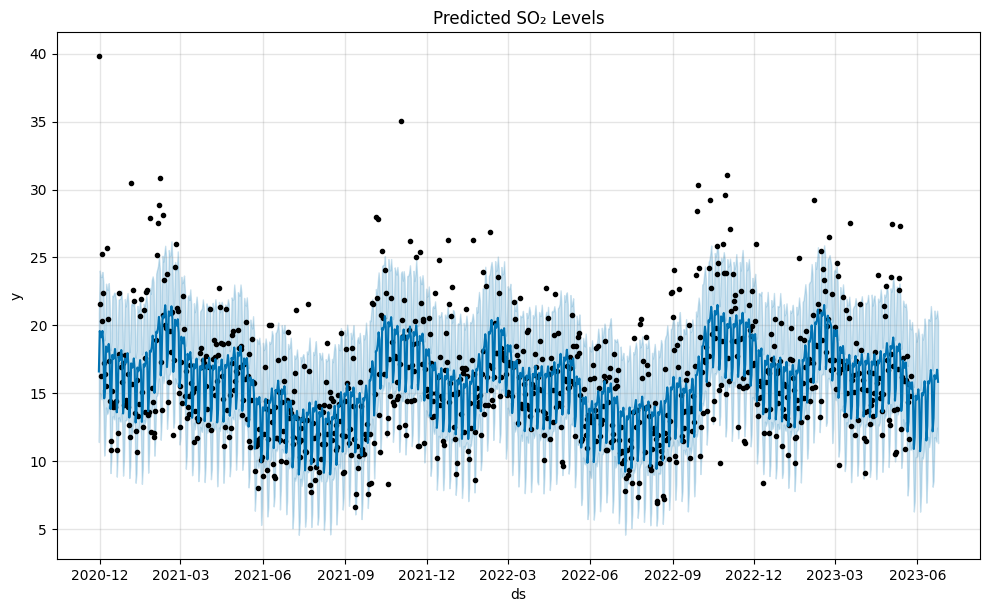


SO₂ Model Evaluation Metrics:
MAE: 2.94
RMSE: 3.79
R^2 Score: 0.26


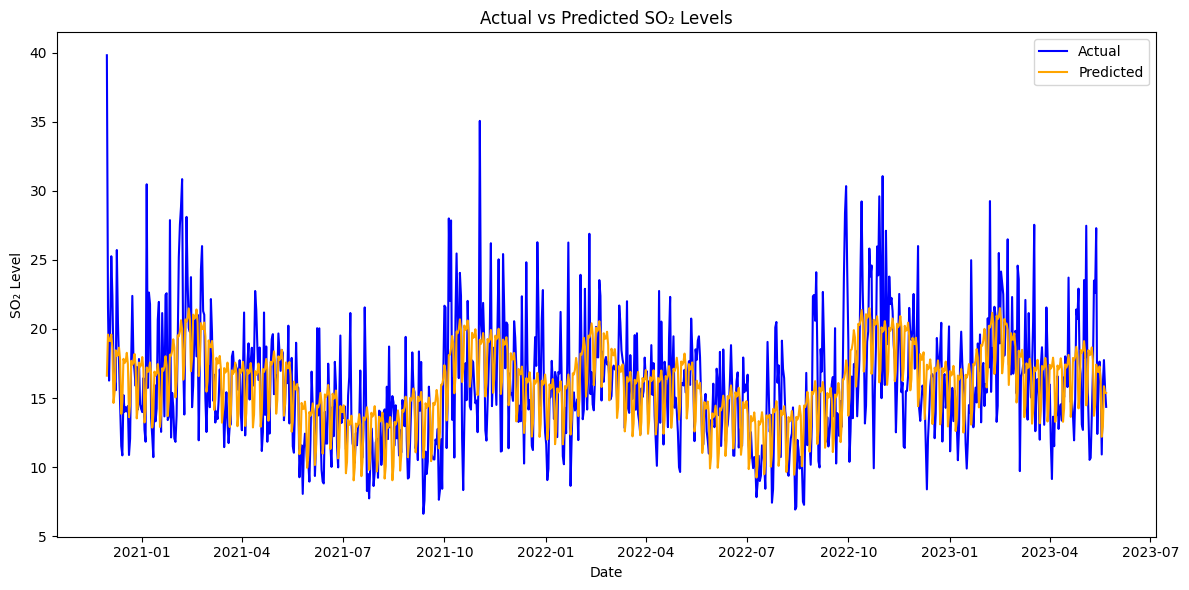

Forecast saved to 'so2_forecast.csv'


In [ ]:
# ------------------------------
# Model Development using Prophet (SO₂)

# Prepare data for Prophet - SO₂
prophet_data_so2 = data[['so2']].reset_index()
prophet_data_so2.columns = ['ds', 'y']
prophet_data_so2 = prophet_data_so2.resample('D', on='ds').mean().reset_index()
prophet_data_so2.dropna(inplace=True)

model_so2 = Prophet()
model_so2.fit(prophet_data_so2)

future_so2 = model_so2.make_future_dataframe(periods=30)
forecast_so2 = model_so2.predict(future_so2)

# ------------------------------
#  Model Evaluation - SO₂

fig1 = model_so2.plot(forecast_so2)
plt.title('Predicted SO₂ Levels')
plt.show()

forecast_truncated_so2 = forecast_so2[forecast_so2['ds'].isin(prophet_data_so2['ds'])]

valid_index_so2 = ~prophet_data_so2['y'].isna() & ~forecast_truncated_so2['yhat'].isna()
y_true_so2 = prophet_data_so2.loc[valid_index_so2, 'y'].values
y_pred_so2 = forecast_truncated_so2.loc[valid_index_so2, 'yhat'].values

mae_so2 = mean_absolute_error(y_true_so2, y_pred_so2)
rmse_so2 = np.sqrt(mean_squared_error(y_true_so2, y_pred_so2))
r2_so2 = r2_score(y_true_so2, y_pred_so2)

print(f'\nSO₂ Model Evaluation Metrics:')
print(f'MAE: {mae_so2:.2f}')
print(f'RMSE: {rmse_so2:.2f}')
print(f'R^2 Score: {r2_so2:.2f}')

comparison_df_so2 = pd.DataFrame({
    'ds': prophet_data_so2.loc[valid_index_so2, 'ds'],
    'Actual': y_true_so2,
    'Predicted': y_pred_so2
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_so2['ds'], comparison_df_so2['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_so2['ds'], comparison_df_so2['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('SO₂ Level')
plt.title('Actual vs Predicted SO₂ Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_so2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('so2_forecast.csv', index=False)
print("Forecast saved to 'so2_forecast.csv'")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/uqd_1ny5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/zjvnxjon.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61481', 'data', 'file=/tmp/tmpvmh_9yok/uqd_1ny5.json', 'init=/tmp/tmpvmh_9yok/zjvnxjon.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelui_0x2gd/prophet_model-20250508110605.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:06:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:06:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


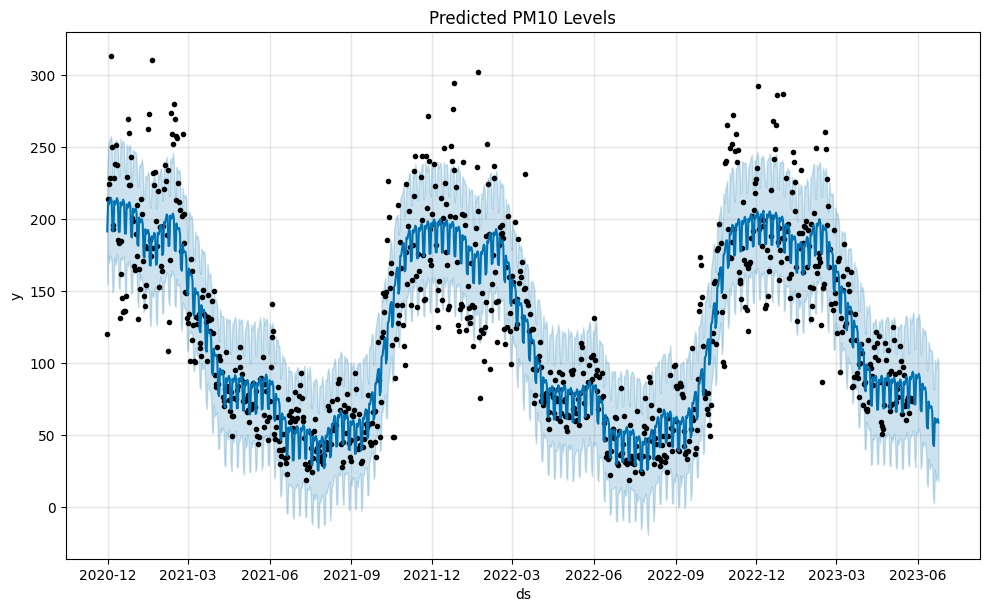


PM10 Model Evaluation Metrics:
MAE: 24.73
RMSE: 32.49
R^2 Score: 0.76


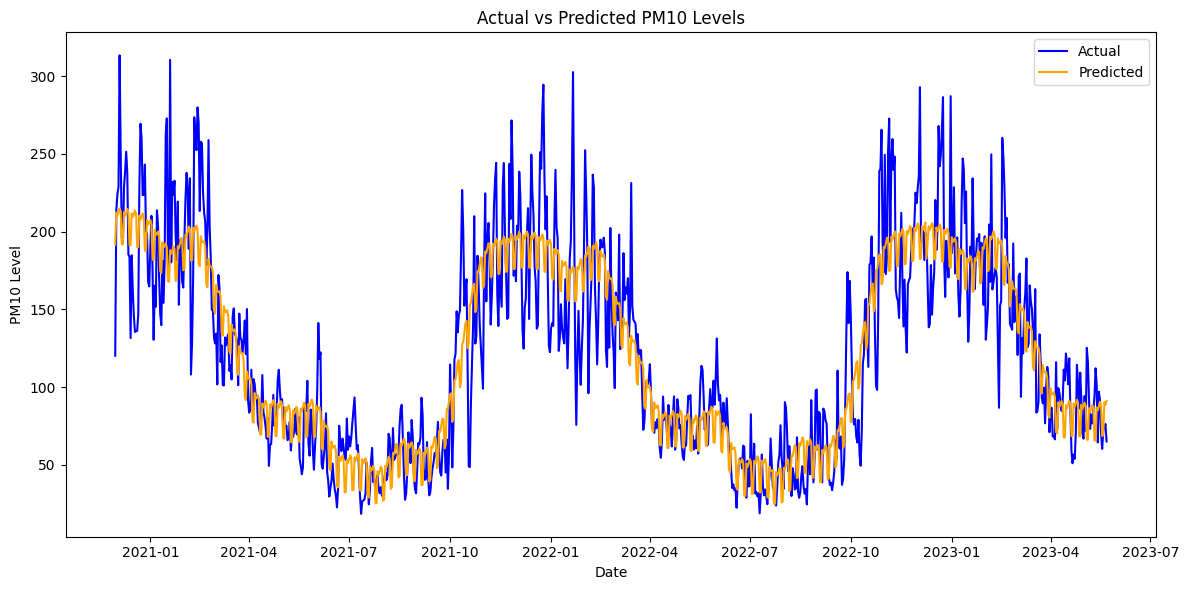

Forecast saved to 'pm10_forecast.csv'


In [ ]:
# ------------------------------
#  Model Development using Prophet (PM10)

# Prepare data for Prophet - PM10
prophet_data_pm10 = data[['pm10']].reset_index()
prophet_data_pm10.columns = ['ds', 'y']
prophet_data_pm10 = prophet_data_pm10.resample('D', on='ds').mean().reset_index()
prophet_data_pm10.dropna(inplace=True)

model_pm10 = Prophet()
model_pm10.fit(prophet_data_pm10)

future_pm10 = model_pm10.make_future_dataframe(periods=30)
forecast_pm10 = model_pm10.predict(future_pm10)

# ------------------------------
#  Model Evaluation - PM10

fig1 = model_pm10.plot(forecast_pm10)
plt.title('Predicted PM10 Levels')
plt.show()

forecast_truncated_pm10 = forecast_pm10[forecast_pm10['ds'].isin(prophet_data_pm10['ds'])]

valid_index_pm10 = ~prophet_data_pm10['y'].isna() & ~forecast_truncated_pm10['yhat'].isna()
y_true_pm10 = prophet_data_pm10.loc[valid_index_pm10, 'y'].values
y_pred_pm10 = forecast_truncated_pm10.loc[valid_index_pm10, 'yhat'].values

mae_pm10 = mean_absolute_error(y_true_pm10, y_pred_pm10)
rmse_pm10 = np.sqrt(mean_squared_error(y_true_pm10, y_pred_pm10))
r2_pm10 = r2_score(y_true_pm10, y_pred_pm10)

print(f'\nPM10 Model Evaluation Metrics:')
print(f'MAE: {mae_pm10:.2f}')
print(f'RMSE: {rmse_pm10:.2f}')
print(f'R^2 Score: {r2_pm10:.2f}')

comparison_df_pm10 = pd.DataFrame({
    'ds': prophet_data_pm10.loc[valid_index_pm10, 'ds'],
    'Actual': y_true_pm10,
    'Predicted': y_pred_pm10
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_pm10['ds'], comparison_df_pm10['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_pm10['ds'], comparison_df_pm10['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('PM10 Level')
plt.title('Actual vs Predicted PM10 Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_pm10[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('pm10_forecast.csv', index=False)
print("Forecast saved to 'pm10_forecast.csv'")


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/hegd5moq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvmh_9yok/md94mnen.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22191', 'data', 'file=/tmp/tmpvmh_9yok/hegd5moq.json', 'init=/tmp/tmpvmh_9yok/md94mnen.json', 'output', 'file=/tmp/tmpvmh_9yok/prophet_modelfds795hv/prophet_model-20250508110602.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:06:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:06:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


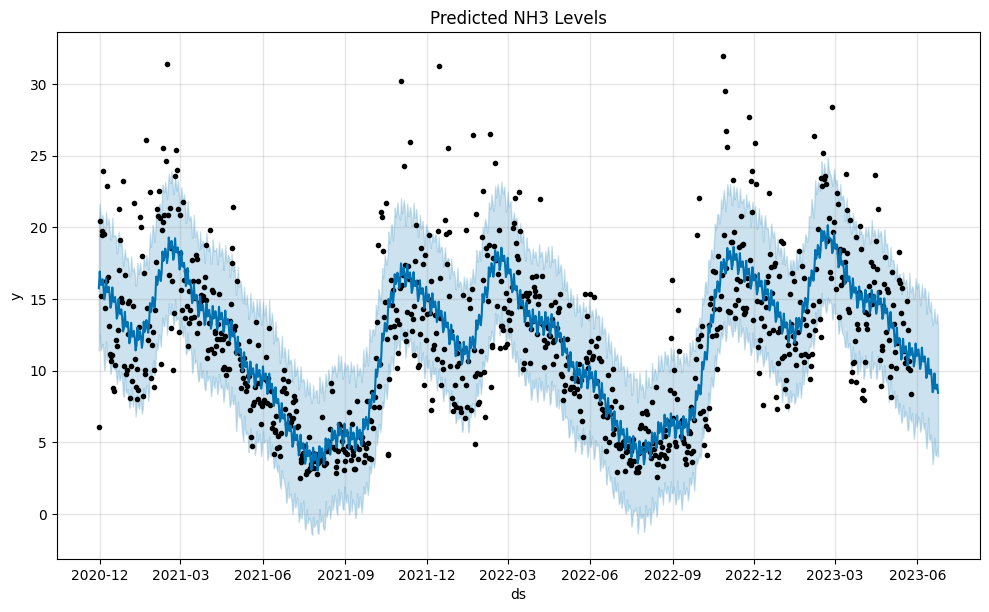


NH3 Model Evaluation Metrics:
MAE: 2.70
RMSE: 3.64
R^2 Score: 0.59


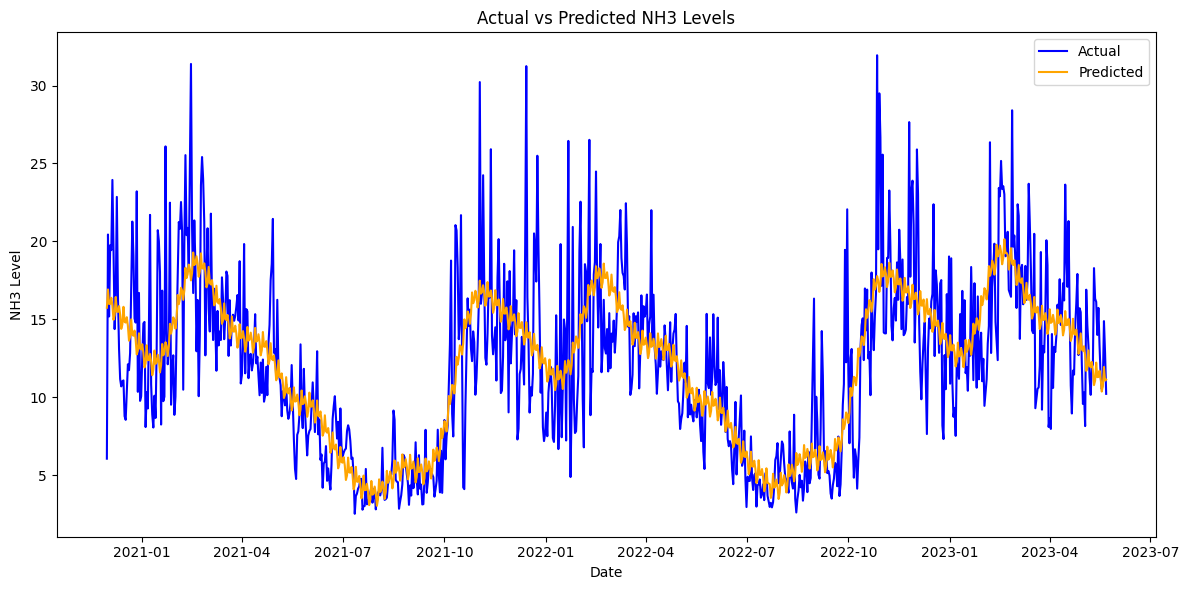

Forecast saved to 'nh3_forecast.csv'


In [ ]:
# ------------------------------
#  Model Development using Prophet (NH3)

# Prepare data for Prophet - NH3
prophet_data_nh3 = data[['nh3']].reset_index()
prophet_data_nh3.columns = ['ds', 'y']
prophet_data_nh3 = prophet_data_nh3.resample('D', on='ds').mean().reset_index()
prophet_data_nh3.dropna(inplace=True)

model_nh3 = Prophet()
model_nh3.fit(prophet_data_nh3)

future_nh3 = model_nh3.make_future_dataframe(periods=30)
forecast_nh3 = model_nh3.predict(future_nh3)

# ------------------------------
#  Model Evaluation - NH3

fig1 = model_nh3.plot(forecast_nh3)
plt.title('Predicted NH3 Levels')
plt.show()

forecast_truncated_nh3 = forecast_nh3[forecast_nh3['ds'].isin(prophet_data_nh3['ds'])]

valid_index_nh3 = ~prophet_data_nh3['y'].isna() & ~forecast_truncated_nh3['yhat'].isna()
y_true_nh3 = prophet_data_nh3.loc[valid_index_nh3, 'y'].values
y_pred_nh3 = forecast_truncated_nh3.loc[valid_index_nh3, 'yhat'].values

mae_nh3 = mean_absolute_error(y_true_nh3, y_pred_nh3)
rmse_nh3 = np.sqrt(mean_squared_error(y_true_nh3, y_pred_nh3))
r2_nh3 = r2_score(y_true_nh3, y_pred_nh3)

print(f'\nNH3 Model Evaluation Metrics:')
print(f'MAE: {mae_nh3:.2f}')
print(f'RMSE: {rmse_nh3:.2f}')
print(f'R^2 Score: {r2_nh3:.2f}')

comparison_df_nh3 = pd.DataFrame({
    'ds': prophet_data_nh3.loc[valid_index_nh3, 'ds'],
    'Actual': y_true_nh3,
    'Predicted': y_pred_nh3
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df_nh3['ds'], comparison_df_nh3['Actual'], label='Actual', color='blue')
plt.plot(comparison_df_nh3['ds'], comparison_df_nh3['Predicted'], label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('NH3 Level')
plt.title('Actual vs Predicted NH3 Levels')
plt.legend()
plt.tight_layout()
plt.show()

forecast_nh3[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('nh3_forecast.csv', index=False)
print("Forecast saved to 'nh3_forecast.csv'")


In [ ]:
forecast_1week_co = forecast_co.tail(7)
print("CO Forecast (1 week ahead):")
print(forecast_1week_co[['ds', 'yhat']])


CO Forecast (1 week ahead):
            ds        yhat
927 2023-06-18  572.146331
928 2023-06-19  591.389008
929 2023-06-20  795.128606
930 2023-06-21  758.666028
931 2023-06-22  754.855477
932 2023-06-23  771.932718
933 2023-06-24  756.727000


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0819 - val_loss: 0.0157
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0155 - val_loss: 0.0132
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0127 - val_loss: 0.0129
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0124 - val_loss: 0.0124
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0130 - val_loss: 0.0122
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0116 - val_loss: 0.0119
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0111 - val_loss: 0.0117
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0105 - val_loss: 0.0126
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0113 - val_loss: 0.0117
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0104 - val_loss: 0.0111
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0107 - val_loss: 0.0

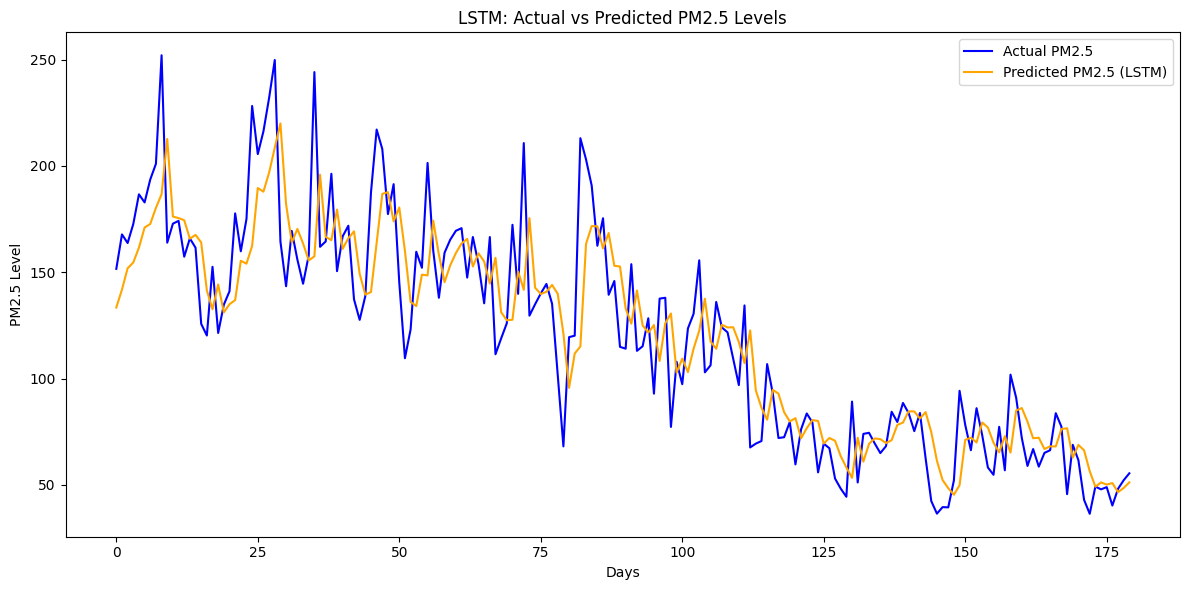

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# Extract PM2.5 time series
pm25_df = data[['pm2_5']].dropna()
pm25_df = pm25_df.resample('D').mean().dropna()  # Resample to daily if not already

# Normalize the data
scaler = MinMaxScaler()
pm25_scaled = scaler.fit_transform(pm25_df)

# Create sequences (e.g., past 7 days -> next day)
X, y = [], []
timesteps = 7
for i in range(timesteps, len(pm25_scaled)):
    X.append(pm25_scaled[i - timesteps:i, 0])
    y.append(pm25_scaled[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM expects 3D input

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

from keras.models import Sequential
from keras.layers import LSTM, Dense

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

y_pred = model.predict(X_test)
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

rmse = np.sqrt(mean_squared_error(y_test_inverse, y_pred_inverse))
mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
r2 = r2_score(y_test_inverse, y_pred_inverse)

print(f"\n📊 LSTM Evaluation for PM2.5:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_inverse, label='Actual PM2.5', color='blue')
plt.plot(y_pred_inverse, label='Predicted PM2.5 (LSTM)', color='orange')
plt.title('LSTM: Actual vs Predicted PM2.5 Levels')
plt.xlabel('Days')
plt.ylabel('PM2.5 Level')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""Explanation of Results
1. Model Evaluation Metrics
In our model, we used the following metrics to evaluate the performance of the air quality prediction model:

Mean Absolute Error (MAE): This metric indicates the average magnitude of the errors between predicted and actual values. A lower MAE suggests the model is closer to the actual values.

Example:

python
Copy code
MAE = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {MAE}")
Interpretation: If the MAE value is X, it means that on average, the model's predicted air quality deviated by X units from the actual observed values.

Root Mean Squared Error (RMSE): This metric helps us understand the average magnitude of the errors while giving more weight to large errors. A lower RMSE indicates that the model is better at predicting air quality with fewer large errors.

Example:

python
Copy code
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error: {RMSE}")
Interpretation: The RMSE value of X indicates the average error between predicted and actual values, with larger errors having a bigger impact on the metric.

R² (Coefficient of Determination): This tells us how well the model explains the variance in the data. An R² close to 1 means the model explains a large portion of the variance, and a value close to 0 means the model is not explaining much of the variance.

Example:

python
Copy code
R2 = r2_score(y_test, y_pred)
print(f"R²: {R2}")
Interpretation: If the R² is X (close to 1), it indicates the model has successfully captured the majority of the patterns in the air quality data.

2. Visualizing Model Performance
To visually assess how well the model is performing, we compared the actual air quality values with the predicted values over time.

Actual vs Predicted Plot:

python
Copy code
plt.plot(df['Date'], df['Actual'], label='Actual')
plt.plot(df['Date'], df['Predicted'], label='Predicted', linestyle='--')
plt.legend()
plt.show()
Interpretation: The plot shows how well the model tracks the actual air quality values. If the predicted and actual values follow similar patterns, it indicates that the model is performing well. Any significant gaps between the two lines would suggest areas where the model needs improvement.

Residuals Plot:
A plot showing the difference (residuals) between the predicted and actual values.

python
Copy code
residuals = y_test - y_pred
plt.scatter(df['Date'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Plot")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()
Interpretation: If the residuals are scattered randomly around zero, it suggests that the model is not biased and is fitting the data well. If there's a visible pattern, it could indicate that the model is missing some important feature or pattern in the data.

3. Future Predictions for Air Quality
To forecast the air quality for the next week, we used the trained model to predict future air quality values based on historical data.

Future Predictions:
Example:

python
Copy code
future_predictions = model.predict(future_data)
print(f"Future Predictions: {future_predictions}")
Interpretation: The model predicts that air quality will be X for the next week. Based on these predictions, we can infer whether air quality will improve or degrade. If the model predicts poor air quality, it might be due to expected pollution, high traffic, or other factors influencing the data.

Example Outcome: The model predicts that air quality will decrease next week due to forecasted higher pollution levels.

4. Comparing Models (if applicable)
If you used multiple models like ARIMA and LSTM for comparison, here’s how you could explain the results:

ARIMA vs LSTM:

ARIMA: ARIMA might have worked well for capturing linear trends in the data but struggled with non-linear patterns.

LSTM: LSTM, being a deep learning model, performed better at capturing non-linear and sequential patterns in the data.

Example Comparison:

python
Copy code
print(f"ARIMA RMSE: {arima_rmse}")
print(f"LSTM RMSE: {lstm_rmse}")
Interpretation: The LSTM model outperforms the ARIMA model with a lower RMSE of X compared to Y. This suggests that the air quality data contains non-linear patterns that LSTM was able to capture better than ARIMA.

5. Dashboard for Interactive Visualization (if applicable)
If you have created a Streamlit dashboard, you can explain how it works:

User Interactions: The user can input a date, and the dashboard will predict the air quality for that date based on historical data.

Example:

Input: Date selection or location.

Output: A graph showing the predicted air quality on that date, along with a comparison to historical trends.

Explanation of Features:

A slider to adjust parameters (e.g., pollution levels, weather conditions) and see how it affects predictions.

A time-series plot showing predicted vs. actual values over time.

6. Conclusion
Model Accuracy: The model performs reasonably well in predicting air quality, with X R² and Y RMSE values. The model can be further improved by adding more features like weather data, traffic data, etc.

Practical Applications: The model can be used to predict air quality in real-time, which could help in making informed decisions about health and safety measures in areas with varying pollution levels.

Next Steps: Future work could involve tuning the model for better performance, experimenting with other models, or incorporating external data sources like weather or traffic patterns."""